<a href="https://colab.research.google.com/github/AdrionRosanelli/LoRa_Sionna/blob/main/Lora_Phy_Tx_Block.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Teste de Implementação do Transmissor LoRa no Sionna PHY usando Block.**

Implementação realizada a usando a estrutura de block do Sionna:

    

# Implementação do transmissor da camada física do LoRa

*   Implementa geração de chirps
*   Modulação utilizando os chirps
*   Codifica dados em símbolos
*   Gera pacotes do LoRa

### Imports

Instalação e importação das bibliotecas. (Import do tutorial Part 1 Sionna PHY)

In [10]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For plotting
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time

In [11]:
#from sionna.phy.channel import OFDMChannel, RayleighBlockFading
#from sionna.phy.mimo import StreamManagement
#from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer
#from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
#from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource
#from sionna.phy.utils import ebnodb2no, sim_ber
import sionna

from sionna.phy import Block
from sionna.phy.config import Config
from sionna.phy.utils import expand_to_rank
from sionna.phy.mapping import BinarySource
from sionna.phy.fec.crc import CRCEncoder

### Implementação da camada física do LoRa no bloco.

1. Inicialização

  *   Define parâmetros do LoRa.

2. Geração de chirps do LoRa:

  *   Chirp linear variando de 0 a BW.

3. Modulação usando chirp.

4. Calculo da frequência instantânea.

5. Geração de pacotes:

  *   Preâmbulo.
  *   Sincronismo.
  *   Cabeçalho.
  *   Payload.

6. Codificação dos bits

7. Analise do chirp

In [12]:
class LoRaPhyTransmitter(Block):
    """
    Implementação da camada física do transmissor LoRa usando Sionna e tensores TensorFlow
    """

    def __init__(self,
                 spreading_factor=7,      # SF7 = 128 chips por símbolo
                 bandwidth=125e3,         # 125 kHz
                 coding_rate=1,           # Taxa de codificação (1=4/5, 2=4/6, 3=4/7, 4=4/8)
                 num_preamble=8,          # Símbolos de preâmbulo
                 sync_word=0x34,          # Palavra de sincronização
                 crc_on=True,            # Habilitar CRC
                 carrier_freq=None,       # Frequência da portadora (Hz), None para desabilitar
                 whitening_on=True,       # Habilitar whitening
                 precision=None,
                 **kwargs):

        super().__init__(precision=precision,**kwargs)

        self.sf = spreading_factor
        self.bw = tf.constant(bandwidth, dtype=tf.float32)
        self.cr = coding_rate
        self.num_preamble = num_preamble
        self.sync_word = sync_word
        self.crc_on = crc_on
        self.carrier_freq = carrier_freq
        self.whitening_on = whitening_on

        # Parâmetros derivados
        self.n_chips = 2**self.sf  # Número de chips por símbolo
        self.symbol_duration = tf.constant(self.n_chips / bandwidth, dtype=tf.float32)
        self.chip_duration = tf.constant(1.0 / bandwidth, dtype=tf.float32)

        # Polinômio CRC-16-CCITT (usado no LoRa)
        self.crc_poly = 0x1021
        self.crc_encoder = CRCEncoder(crc_degree="CRC16")

        # Polinômio CRC-4 para cabeçalho: x^4 + x + 1 (0x13 em hexadecimal)
        self.header_crc_poly = 0x13

        # Polinômio e semente para whitening (novo padrão)
        # Polinômio: x^8 + x^6 + x^5 + x^4 + 1 (0x170 em hexadecimal)
        self.whitening_poly = 0x170
        self.whitening_seed = 0xFF  # Semente inicial (8 bits = 0xFF)

        # Pre-computar vetores de tempo para eficiência
        self._build_time_vectors()

        # Inicializar matrizes para codificação de Hamming
        self._build_hamming_matrices()

    def build(self, input_shapes):
        """
        Método build específico do Block - executado na primeira chamada
        Permite inicialização baseada nas formas de entrada
        """
        super().build(input_shapes)

        # Validar formato de entrada
        if len(input_shapes) > 2:
            raise ValueError("Entrada deve ter no máximo 2 dimensões: [batch_size, num_bits] ou [num_bits]")

        # Configurar processamento baseado na forma de entrada
        if len(input_shapes) == 1:
            self.batch_processing = False
        else:
            self.batch_processing = True

        print(f"LoRa Transmitter configurado para entrada: {input_shapes}")

    def _build_time_vectors(self):
        """
        Pre-computa vetores de tempo para os símbolos
        """
        step = self.symbol_duration / self.n_chips
        self.t_symbol = tf.linspace(0.0, self.symbol_duration - step, self.n_chips)

    def _build_hamming_matrices(self):
        """
        Constrói as matrizes geradoras e de paridade para codificação de Hamming (4,8)
        usadas no LoRa baseadas na taxa de codificação (CR)

        LoRa usa diferentes taxas de codificação:
        - CR = 1: 4/5 (4 bits de dados, 1 bit de paridade)
        - CR = 2: 4/6 (4 bits de dados, 2 bits de paridade)
        - CR = 3: 4/7 (4 bits de dados, 3 bits de paridade)
        - CR = 4: 4/8 (4 bits de dados, 4 bits de paridade) - Hamming completo
        """

        # Matriz geradora para Hamming (4,8) - versão sistemática
        # Formato: [I4 | P] onde I4 é identidade 4x4 e P é paridade 4x4
        if self.cr == 4:  # Hamming (4,8) completo
            # Matriz de paridade para Hamming (4,8)
            P = tf.constant([
                [1, 1, 1, 0],  # bit paridade 1: XOR dos bits 0,1,2
                [1, 1, 0, 1],  # bit paridade 2: XOR dos bits 0,1,3
                [1, 0, 1, 1],  # bit paridade 3: XOR dos bits 0,2,3
                [0, 1, 1, 1]   # bit paridade 4: XOR dos bits 1,2,3
            ], dtype=tf.int32)

        elif self.cr == 3:  # 4/7 - 3 bits de paridade
            P = tf.constant([
                [1, 1, 1, 0],
                [1, 1, 0, 1],
                [1, 0, 1, 1]
            ], dtype=tf.int32)

        elif self.cr == 2:  # 4/6 - 2 bits de paridade
            P = tf.constant([
                [1, 1, 1, 0],
                [1, 1, 0, 1]
            ], dtype=tf.int32)

        elif self.cr == 1:  # 4/5 - 1 bit de paridade
            P = tf.constant([
                [1, 1, 1, 0]
            ], dtype=tf.int32)
        else:
            # Sem codificação (CR = 0 não é padrão, mas permite passar dados direto)
            P = tf.constant([], shape=(0, 4), dtype=tf.int32)

        # Matriz identidade 4x4 para parte sistemática
        I4 = tf.eye(4, dtype=tf.int32)

        # Matriz geradora G = [I4 | P^T] (transposta de P para formato correto)
        if tf.shape(P)[0] > 0:
            self.G = tf.concat([I4, tf.transpose(P)], axis=1)
            self.code_length = 4 + self.cr
        else:
            self.G = I4  # Sem codificação
            self.code_length = 4

        # Matriz de verificação de paridade H = [P | I_cr] para decodificação
        if self.cr > 0:
            I_cr = tf.eye(self.cr, dtype=tf.int32)
            self.H = tf.concat([P, I_cr], axis=1)
        else:
            self.H = tf.constant([], shape=(0, 4), dtype=tf.int32)

    def generate_chirp_sequence(self, initial_frequency=0.0, down_chirp=False):
        """
        Gera sequência chirp característica do LoRa usando tensores

        Args:
            initial_frequency: Frequência inicial do chirp (Hz)
            down_chirp: Se True, gera down-chirp; se False, gera up-chirp

        Returns:
            chirp: Tensor complexo com o sinal chirp
        """
        # Converter para tensor se necessário
        initial_freq = tf.cast(initial_frequency, tf.float32)

        # Chirp linear com frequência variando de 0 a BW
        if down_chirp:
            freq_slope = -self.bw / self.symbol_duration
        else:
            freq_slope = self.bw / self.symbol_duration

        # Calcular fase instantânea
        phase = 2.0 * np.pi * (
            initial_freq * self.t_symbol +
            0.5 * freq_slope * tf.square(self.t_symbol)
        )

        # Gerar chirp complexo - separando parte real e imaginária para tensor complexo
        real_part = tf.cos(phase)
        imag_part = tf.sin(phase)
        chirp = tf.complex(real_part, imag_part)

        # Converter para o tipo complexo correto do Block
        chirp = tf.cast(chirp, self.cdtype)

        return chirp

    def modulate_symbol(self, symbol_value):
        """
        Modula um símbolo usando modulação chirp do LoRa

        Args:
            symbol_value: Valor do símbolo (0 a 2^SF - 1)

        Returns:
            chirp: Tensor complexo com o sinal modulado
        """
        # Frequência offset baseada no valor do símbolo
        symbol_val = tf.cast(symbol_value, tf.float32)
        freq_offset = (symbol_val * self.bw) / tf.cast(self.n_chips, tf.float32)

        chirp = self.generate_chirp_sequence(freq_offset)
        return chirp

    @tf.function
    def binary_to_gray(self, binary_value):
        """
        Converte um valor binário para código Gray

        Args:
            binary_value: Tensor com valores binários (inteiros)

        Returns:
            gray_value: Tensor com valores em código Gray
        """
        # Gray code = binary XOR (binary >> 1)
        gray = tf.bitwise.bitwise_xor(
            binary_value,
            tf.bitwise.right_shift(binary_value, 1)
        )
        return gray

    @tf.function
    def encode_data_tensor(self, data_bits):
        """
        Codifica dados em símbolos LoRa usando operações tensoriais com Gray mapping

        O LoRa utiliza Gray mapping para converter bits em símbolos, onde símbolos
        adjacentes diferem por apenas 1 bit, reduzindo a taxa de erro de bits.

        Args:
            data_bits: Tensor 1D com bits de dados [num_bits]

        Returns:
            symbols: Tensor complexo [num_symbols, n_chips]
        """
        # Calcular número de símbolos necessários
        num_bits = tf.shape(data_bits)[0]
        num_symbols = tf.cast(tf.math.ceil(num_bits / self.sf), tf.int32)

        # Fazer padding dos bits se necessário
        padded_bits = tf.pad(data_bits, [[0, num_symbols * self.sf - num_bits]])

        # Reshape para [num_symbols, sf]
        symbol_bits = tf.reshape(padded_bits, [num_symbols, self.sf])

        # Converter bits para valores binários (0 a 2^SF - 1)
        powers_of_2 = tf.cast(tf.pow(2.0, tf.range(self.sf, dtype=tf.float32)), tf.int32)
        binary_values = tf.reduce_sum(
            tf.cast(symbol_bits, tf.int32) * powers_of_2[tf.newaxis, :],
            axis=1
        )

        # Aplicar Gray mapping (conversão binário -> Gray)
        # No LoRa, os símbolos são mapeados usando código Gray para minimizar erros
        gray_values = self.binary_to_gray(binary_values)

        # Modular todos os símbolos usando os valores Gray
        symbols = tf.map_fn(
            lambda x: self.modulate_symbol(x),
            gray_values,
            fn_output_signature=tf.TensorSpec(shape=[self.n_chips], dtype=self.cdtype),
            parallel_iterations=10
        )

        return symbols

    @tf.function
    def generate_preamble(self):
        """
        Gera preâmbulo LoRa

        Returns:
            preamble: Tensor complexo [num_preamble, n_chips]
        """
        # Up-chirps para preâmbulo
        base_chirp = self.generate_chirp_sequence(-self.bw/2.0)
        preamble = tf.tile(base_chirp[tf.newaxis, :], [self.num_preamble, 1])
        return preamble

    @tf.function
    def generate_sync_word(self):
        """
        Gera palavra de sincronização

        Returns:
            sync_symbols: Tensor complexo [1, n_chips]
        """
        sync_symbol = self.modulate_symbol(self.sync_word)
        return sync_symbol[tf.newaxis, :]

    @tf.function
    def generate_down_chirps(self):
        """
        Gera 2.25 down-chirps após sincronização

        Returns:
            down_chirps: Tensor complexo [total_samples]
        """
        # Down-chirp completo
        down_chirp = self.generate_chirp_sequence(self.bw/2.0, down_chirp=True)

        # 2 down-chirps completos
        full_chirps = tf.tile(down_chirp[tf.newaxis, :], [2, 1])
        full_chirps = tf.reshape(full_chirps, [-1])

        # 0.25 down-chirp
        quarter_length = self.n_chips // 4
        quarter_chirp = down_chirp[:quarter_length]

        # Concatenar
        down_chirps = tf.concat([full_chirps, quarter_chirp], axis=0)

        return down_chirps

    @tf.function
    def calculate_header_crc4(self, header_bits):
        """
        Calcula CRC-4 para o cabeçalho LoRa
        Polinômio: x^4 + x + 1 (0x13)

        Args:
            header_bits: Tensor 1D com 16 bits do cabeçalho [16]

        Returns:
            crc: Tensor com 4 bits de CRC [4]
        """
        # Converter bits para valor inteiro para cálculo do CRC
        powers_of_2 = tf.cast(tf.pow(2.0, tf.range(15, -1, -1, dtype=tf.float32)), tf.int32)
        header_value = tf.reduce_sum(
            tf.cast(header_bits, tf.int32) * powers_of_2
        )

        # Algoritmo CRC-4
        # Inicializar registrador com os primeiros 4 bits
        crc = tf.bitwise.bitwise_and(tf.bitwise.right_shift(header_value, 12), 0xF)

        # Processar cada um dos 16 bits
        def process_bit(i, crc_state, data):
            # Extrair próximo bit dos dados
            bit_pos = 15 - i
            data_bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(data, bit_pos), 1
            )

            # XOR com MSB do CRC
            msb = tf.bitwise.bitwise_and(tf.bitwise.right_shift(crc_state, 3), 1)

            # Shift left
            crc_state = tf.bitwise.left_shift(crc_state, 1)
            crc_state = tf.bitwise.bitwise_and(crc_state, 0xF)

            # XOR com data bit
            crc_state = tf.bitwise.bitwise_xor(crc_state, data_bit)

            # Se MSB era 1, aplicar polinômio (0x3 = x + 1)
            polynomial = tf.where(tf.equal(msb, 1), 0x3, 0)
            crc_state = tf.bitwise.bitwise_xor(crc_state, polynomial)

            return i + 1, crc_state, data

        # Processar todos os 16 bits
        _, final_crc, _ = tf.while_loop(
            lambda i, crc_state, data: i < 16,
            process_bit,
            [0, crc, header_value]
        )

        # Converter CRC para bits
        crc_bits = tf.TensorArray(dtype=tf.int32, size=4)

        def extract_bits(i, crc_val, bits_array):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(crc_val, 3 - i), 1
            )
            bits_array = bits_array.write(i, bit)
            return i + 1, crc_val, bits_array

        _, _, crc_bits = tf.while_loop(
            lambda i, crc_val, bits_array: i < 4,
            extract_bits,
            [0, final_crc, crc_bits]
        )

        return crc_bits.stack()

    @tf.function
    def generate_header(self, payload_length):
        """
        Gera cabeçalho LoRa (PHDR) com estrutura completa de 20 bits

        Estrutura do PHDR:
        - Payload Length: 8 bits (0-255 bytes)
        - Coding Rate: 3 bits (001=4/5, 010=4/6, 011=4/7, 100=4/8)
        - CRC Present: 1 bit (0=sem CRC, 1=com CRC)
        - Reserved: 4 bits (0000)
        - Header CRC: 4 bits (CRC-4 dos 16 bits anteriores)

        Args:
            payload_length: Comprimento do payload em bits

        Returns:
            header_bits: Tensor 1D com 20 bits do cabeçalho completo [20]
        """
        # 1. Payload Length (8 bits) - converter bits para bytes
        payload_bytes = payload_length // 8
        payload_bytes = tf.minimum(payload_bytes, 255)  # Limitar a 255

        # Converter para bits (MSB first)
        length_bits = tf.TensorArray(dtype=tf.int32, size=8)

        def extract_length_bits(i, val, bits_array):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(val, 7 - i), 1
            )
            bits_array = bits_array.write(i, bit)
            return i + 1, val, bits_array

        _, _, length_bits = tf.while_loop(
            lambda i, val, bits_array: i < 8,
            extract_length_bits,
            [0, payload_bytes, length_bits]
        )

        length_bits_tensor = length_bits.stack()

        # 2. Coding Rate (3 bits)
        # CR: 1=001, 2=010, 3=011, 4=100
        cr_bits = tf.TensorArray(dtype=tf.int32, size=3)

        def extract_cr_bits(i, val, bits_array):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(val, 2 - i), 1
            )
            bits_array = bits_array.write(i, bit)
            return i + 1, val, bits_array

        _, _, cr_bits = tf.while_loop(
            lambda i, val, bits_array: i < 3,
            extract_cr_bits,
            [0, self.cr, cr_bits]
        )

        cr_bits_tensor = cr_bits.stack()

        # 3. CRC Present (1 bit)
        crc_bit = tf.constant([1 if self.crc_on else 0], dtype=tf.int32)

        # 4. Reserved bits (4 bits) - todos zeros
        reserved_bits = tf.zeros([4], dtype=tf.int32)

        # Concatenar os primeiros 16 bits (dados do cabeçalho)
        header_data = tf.concat([
            length_bits_tensor,  # 8 bits
            cr_bits_tensor,      # 3 bits
            crc_bit,             # 1 bit
            reserved_bits        # 4 bits
        ], axis=0)

        # 5. Calcular CRC-4 sobre os 16 bits de dados
        header_crc = self.calculate_header_crc4(header_data)

        # 6. Concatenar cabeçalho completo (20 bits)
        complete_header = tf.concat([header_data, header_crc], axis=0)

        return complete_header

    @tf.function
    def whitening(self, final_payload):
        """
        Aplica whitening (scrambling) aos dados do payload usando LFSR

        O whitening usa um Linear Feedback Shift Register (LFSR) com polinômio
        característico x^8 + x^6 + x^5 + x^4 + 1 para gerar uma sequência pseudo-aleatória que é
        aplicada via XOR aos dados.

        Args:
            final_payload: Tensor 1D com bits do payload [num_bits]

        Returns:
            whitened_payload: Tensor 1D com bits do payload após whitening [num_bits]
        """
        payload_length = tf.shape(final_payload)[0]

        # Inicializar LFSR com semente (8 bits)
        lfsr_state = tf.constant(self.whitening_seed, dtype=tf.int32)

        # Gerar sequência de whitening
        whitening_sequence = tf.TensorArray(dtype=tf.int32, size=payload_length)

        def lfsr_step(i, lfsr_state, whitening_seq):
            # Extrair bit de saída (LSB)
            output_bit = tf.bitwise.bitwise_and(lfsr_state, 1)
            whitening_seq = whitening_seq.write(i, output_bit)

            # Calcular feedback usando o polinômio x^8 + x^6 + x^5 + x^4 + 1
            # Feedback = bit 7 XOR bit 5 XOR bit 4 XOR bit 3 (posições 0-indexadas)
            bit7 = tf.bitwise.bitwise_and(tf.bitwise.right_shift(lfsr_state, 7), 1)  # x^8
            bit5 = tf.bitwise.bitwise_and(tf.bitwise.right_shift(lfsr_state, 5), 1)  # x^6
            bit4 = tf.bitwise.bitwise_and(tf.bitwise.right_shift(lfsr_state, 4), 1)  # x^5
            bit3 = tf.bitwise.bitwise_and(tf.bitwise.right_shift(lfsr_state, 3), 1)  # x^4

            feedback = tf.bitwise.bitwise_xor(bit7,
                      tf.bitwise.bitwise_xor(bit5,
                      tf.bitwise.bitwise_xor(bit4, bit3)))

            # Shift direita e inserir feedback no MSB
            lfsr_state = tf.bitwise.right_shift(lfsr_state, 1)
            lfsr_state = tf.bitwise.bitwise_or(lfsr_state,
                                              tf.bitwise.left_shift(feedback, 7))  # MSB para 8 bits

            # Manter apenas 8 bits
            lfsr_state = tf.bitwise.bitwise_and(lfsr_state, 0xFF)

            return i + 1, lfsr_state, whitening_seq

        # Executar LFSR para gerar sequência de whitening
        _, _, whitening_sequence = tf.while_loop(
            lambda i, lfsr_state, whitening_seq: i < payload_length,
            lfsr_step,
            [0, lfsr_state, whitening_sequence]
        )

        # Converter TensorArray para tensor
        whitening_bits = whitening_sequence.stack()

        # Aplicar whitening via XOR
        whitened_payload = tf.bitwise.bitwise_xor(
            tf.cast(final_payload, tf.int32),
            whitening_bits
        )

        return tf.cast(whitened_payload, tf.int32)


    @tf.function
    def hamming_encode_block(self, data_block):
        """
        Codifica um bloco de 4 bits usando codificação de Hamming

        Args:
            data_block: Tensor 1D com 4 bits de dados [4]

        Returns:
            encoded_block: Tensor 1D com bits codificados [4+CR]
        """
        # Garantir que data_block tenha exatamente 4 bits
        data_4bits = data_block[:4] if tf.shape(data_block)[0] >= 4 else tf.pad(data_block, [[0, 4-tf.shape(data_block)[0]]])

        # Multiplicação matriz-vetor: encoded = data * G
        # Usar operação XOR (mod 2) para aritmética de campo finito
        encoded = tf.linalg.matvec(self.G, data_4bits, transpose_a=True)  # G^T * data
        encoded = tf.math.mod(encoded, 2)  # Operação mod 2 (XOR)

        return tf.cast(encoded, tf.int32)

    @tf.function
    def hamming_encode_tensor(self, data_bits):
        """
        Codifica um tensor de bits usando codificação de Hamming bloco a bloco

        Args:
            data_bits: Tensor 1D com bits de dados [num_bits]

        Returns:
            encoded_bits: Tensor 1D com bits codificados [num_encoded_bits]
        """
        if self.cr == 0:
            return data_bits  # Sem codificação

        num_bits = tf.shape(data_bits)[0]
        num_blocks = tf.cast(tf.math.ceil(num_bits / 4), tf.int32)

        # Padding para completar blocos de 4 bits
        padded_bits = tf.pad(data_bits, [[0, num_blocks * 4 - num_bits]])

        # Reshape para blocos de 4 bits
        data_blocks = tf.reshape(padded_bits, [num_blocks, 4])

        # Codificar cada bloco
        encoded_blocks = tf.map_fn(
            self.hamming_encode_block,
            data_blocks,
            fn_output_signature=tf.TensorSpec(shape=[self.code_length], dtype=tf.int32),
            parallel_iterations=10
        )

        # Flatten resultado
        encoded_bits = tf.reshape(encoded_blocks, [-1])

        return encoded_bits

    @tf.function
    def interleaving(self, coded_bits):
        """
        Aplica interleaving aos bits codificados para melhorar resistência a erro em rajada
        O LoRa usa interleaving diagonal para distribuir bits de um símbolo por múltiplos símbolos

        Args:
            coded_bits: Tensor 1D com bits codificados

        Returns:
            interleaved_bits: Tensor 1D com bits intercalados
        """
        num_bits = tf.shape(coded_bits)[0]

        # Calcular dimensões da matriz de interleaving
        # Usar SF como largura da matriz (distribui bits pelos símbolos)
        matrix_width = self.sf
        matrix_height = tf.cast(tf.math.ceil(num_bits / matrix_width), tf.int32)

        # Fazer padding se necessário
        padded_bits = tf.pad(coded_bits, [[0, matrix_height * matrix_width - num_bits]])

        # Reshape para matriz
        bit_matrix = tf.reshape(padded_bits, [matrix_height, matrix_width])

        # Interleaving diagonal: ler por colunas ao invés de linhas
        interleaved_matrix = tf.transpose(bit_matrix)
        interleaved_bits = tf.reshape(interleaved_matrix, [-1])

        # Remover padding extra
        interleaved_bits = interleaved_bits[:num_bits]

        return interleaved_bits

###################################...Não usado esse CRC...#####################################
    @tf.function
    def crc16_ccitt_tensor(self, data_bits):
        """
        Calcula CRC-16-CCITT usando operações tensoriais

        Args:
            data_bits: Tensor 1D com bits de dados

        Returns:
            crc_value: Valor CRC como escalar
        """
        # Converter bits para bytes
        num_bits = tf.shape(data_bits)[0]
        num_bytes = tf.cast(tf.math.ceil(num_bits / 8), tf.int32)

        # Padding para múltiplo de 8 bits
        padded_bits = tf.pad(data_bits, [[0, num_bytes * 8 - num_bits]])
        byte_bits = tf.reshape(padded_bits, [num_bytes, 8])

        # Converter para bytes
        powers_of_2 = tf.cast(tf.pow(2.0, tf.range(8, dtype=tf.float32)), tf.int32)
        data_bytes = tf.reduce_sum(
            tf.cast(byte_bits, tf.int32) * powers_of_2[tf.newaxis, :],
            axis=1
        )

        # Implementação CRC usando loop
        crc = tf.constant(0xFFFF, dtype=tf.int32)

        def crc_step(i, crc):
            byte = data_bytes[i]
            crc = tf.bitwise.bitwise_xor(crc, tf.bitwise.left_shift(byte, 8))

            def bit_step(j, crc):
                condition = tf.bitwise.bitwise_and(crc, 0x8000) != 0
                crc_shifted = tf.bitwise.left_shift(crc, 1)
                crc_poly_applied = tf.bitwise.bitwise_xor(crc_shifted, self.crc_poly)
                crc = tf.where(condition, crc_poly_applied, crc_shifted)
                crc = tf.bitwise.bitwise_and(crc, 0xFFFF)
                return j + 1, crc

            _, crc = tf.while_loop(
                lambda j, crc: j < 8,
                bit_step,
                [0, crc]
            )

            return i + 1, crc

        _, crc = tf.while_loop(
            lambda i, crc: i < num_bytes,
            crc_step,
            [0, crc]
        )

        return tf.bitwise.bitwise_xor(crc, 0xFFFF)

    @tf.function
    def crc_to_bits_tensor(self, crc_value):
        """
        Converte valor CRC para bits (LSB primeiro)

        Args:
            crc_value: Valor CRC como escalar

        Returns:
            crc_bits: Tensor 1D com 16 bits
        """
        bits = []
        for i in range(16):
            bit = tf.bitwise.bitwise_and(
                tf.bitwise.right_shift(crc_value, i),
                1
            )
            bits.append(tf.cast(bit, tf.int32))

        return tf.stack(bits)
###################################...Não usado esse CRC...#####################################

    def call(self, inputs):
        """
        Processa o sinal de entrada e gera pacote LoRa completo

        Args:
            inputs: Tensor com bits de dados [batch_size, num_bits] ou [num_bits]

        Returns:
            lora_packet: Tensor complexo com pacote LoRa modulado
        """
        # Garantir que inputs seja um tensor e int32 para lógica binaria
        payload_bits = tf.convert_to_tensor(inputs)
        payload_bits = tf.cast(payload_bits, tf.int32)

        # Expandir dimensões se necessário para suportar batch
        if len(payload_bits.shape) == 1:
            payload_bits = payload_bits[tf.newaxis, :]

        batch_size = tf.shape(payload_bits)[0]

        # Processar cada item do batch
        def process_single_packet(payload):
            # 1. Gerar preâmbulo
            preamble = self.generate_preamble()
            preamble_flat = tf.reshape(preamble, [-1])

            # 2. Gerar palavra de sincronização
            sync_word = self.generate_sync_word()
            sync_flat = tf.reshape(sync_word, [-1])

            # 3. Gerar down-chirps
            down_chirps = self.generate_down_chirps()

            # 4. Gerar cabeçalho LoRa (PHDR) com estrutura completa
            payload_length = tf.shape(payload)[0]
            header_bits = self.generate_header(payload_length)

            print(f"\nCabeçalho LoRa (20 bits): {header_bits}")
            print(f"  - Payload Length: {payload_length // 8} bytes")
            print(f"  - Coding Rate: {self.cr}")
            print(f"  - CRC Present: {self.crc_on}")

            # Codificar cabeçalho (aplicar Hamming e Interleaving)
            header_coded = self.hamming_encode_tensor(header_bits)
            header_interleaved = self.interleaving(header_coded)
            header_symbols = self.encode_data_tensor(header_interleaved)
            header_flat = tf.reshape(header_symbols, [-1])

            # 5. Preparar payload com CRC se habilitado
            if self.crc_on:
                # crc_value = self.crc16_ccitt_tensor(payload)
                # crc_bits = self.crc_to_bits_tensor(crc_value)
                # final_payload = tf.concat([payload, crc_bits], axis=0)
                final_payload = self.crc_encoder(payload)
            else:
                final_payload = payload

            # 6. Aplicar whitening se habilitado
            if self.whitening_on:
                print(f"\nPayload Antes de Whitening: {final_payload}")
                final_payload = self.whitening(final_payload)
                print(f"Payload Depois de Whitening: {final_payload}")


            # Aplicar codificação de Hamming
            coded_bits = self.hamming_encode_tensor(final_payload)
            print(f"\nPayload Depois de Hamming: {coded_bits}")

            # Aplicar interleaving
            interleaved_bits = self.interleaving(coded_bits)
            print(f"\nPayload Depois de Interleaving: {interleaved_bits}")

            # 7. Codificar payload (com Hamming e Interleaving)
            payload_symbols = self.encode_data_tensor(interleaved_bits)
            payload_flat = tf.reshape(payload_symbols, [-1])

            # 8. Concatenar todas as partes
            packet_parts = [preamble_flat, sync_flat, down_chirps, header_flat, payload_flat]
            baseband_signal = tf.concat(packet_parts, axis=0)

            # 9. Aplicar modulação da portadora se habilitada
            if self.carrier_freq is not None:
                signal_length = tf.shape(baseband_signal)[0]
                time_vector = tf.linspace(0.0,
                                        tf.cast(signal_length, tf.float32) * self.chip_duration,
                                        signal_length)
                # Criar portadora complexa adequadamente
                carrier_real = tf.cos(2.0 * np.pi * self.carrier_freq * time_vector)
                carrier_imag = tf.sin(2.0 * np.pi * self.carrier_freq * time_vector)
                carrier = tf.complex(carrier_real, carrier_imag)
                carrier = tf.cast(carrier, self.cdtype)

                final_signal = baseband_signal * carrier
            else:
                final_signal = baseband_signal

            return final_signal

        # Aplicar processamento a todo o batch
        if batch_size == 1:
            result = process_single_packet(payload_bits[0])
            return result[tf.newaxis, :]
        else:
            results = tf.map_fn(
                process_single_packet,
                payload_bits,
                fn_output_signature=tf.TensorSpec(shape=[None], dtype=self.cdtype),
                parallel_iterations=1
            )
            return results

#######################################################
## Funções para visualização e analises da implementação:

    def plot_frequency_vs_time(self, packet_signal, title="Variação de Frequência do Pacote LoRa"):
        """
        Plota a variação de frequência instantânea em função do tempo

        Args:
            packet_signal: Sinal do pacote LoRa (tensor complexo)
            title: Título do gráfico
        """
        # Converter para numpy para processamento
        signal = packet_signal.numpy() if hasattr(packet_signal, 'numpy') else packet_signal

        # Calcular frequência instantânea usando diferenciação da fase
        analytic_signal = signal
        phase = np.unwrap(np.angle(analytic_signal))

        # Frequência instantânea = derivada da fase / (2*pi)
        dt = self.chip_duration.numpy()
        freq_inst = np.diff(phase) / (2 * np.pi * dt)

        # Eixo temporal
        time_axis = np.arange(len(freq_inst)) * dt * 1000  # ms

        # Plotar
        plt.figure(figsize=(10, 3))

        # Subplot 1: Frequência instantânea
        # plt.subplot(2, 1, 1)
        plt.plot(time_axis, freq_inst / 1000, 'b-o', linewidth=1, markersize=2)
        plt.title(title)
        plt.xlabel('Tempo (ms)')
        plt.ylabel('Frequência Instantânea (kHz)')
        plt.grid(True, alpha=0.3)

        # Adicionar linhas de referência para bandwidth
        bw_khz = self.bw.numpy() / 1000
        plt.axhline(y=bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'+BW/2 = {bw_khz/2:.1f} kHz')
        plt.axhline(y=-bw_khz/2, color='r', linestyle='--', alpha=0.7, label=f'-BW/2 = {-bw_khz/2:.1f} kHz')
        plt.legend()

        # Subplot 2: Espectrograma
        # plt.subplot(2, 1, 2)

        # # Calcular espectrograma
        # from scipy import signal as scipy_signal
        # nperseg = min(256, len(analytic_signal) // 8)
        # f, t, Sxx = scipy_signal.spectrogram(
        #     analytic_signal,
        #     fs=1/dt,
        #     nperseg=nperseg,
        #     noverlap=nperseg//2,
        #     return_onesided=False
        # )

        # # Converter para escala mais legível
        # f_khz = np.fft.fftshift(f) / 1000  # kHz
        # t_ms = t * 1000  # ms
        # Sxx_shifted = np.fft.fftshift(Sxx, axes=0)

        # plt.pcolormesh(t_ms, f_khz, 10*np.log10(Sxx_shifted + 1e-10), shading='gouraud')
        # plt.title('Espectrograma do Pacote LoRa')
        # plt.xlabel('Tempo (ms)')
        # plt.ylabel('Frequência (kHz)')
        # plt.colorbar(label='Potência (dB)')

        # # Limitar eixo Y ao bandwidth
        # plt.ylim([-bw_khz/2, bw_khz/2])

        plt.tight_layout()
        plt.show()

        return freq_inst, time_axis

###################################...Não usado abaixo...#####################################
    def analyze_chirp_spectrum_tensor(self, symbol_values=[0, None, None, None], plot=True):
        """
        Analisa o espectro dos chirps LoRa usando tensores

        Args:
            symbol_values: Lista com valores de símbolos para análise
                          None será substituído por valores padrão
        """
        # Definir valores padrão para símbolos
        if symbol_values[1] is None:
            symbol_values[1] = self.n_chips // 4
        if symbol_values[2] is None:
            symbol_values[2] = self.n_chips // 2
        if symbol_values[3] is None:
            symbol_values[3] = 3 * self.n_chips // 4

        # Gerar chirps
        chirps = []
        for symbol_val in symbol_values:
            chirp = self.modulate_symbol(symbol_val)
            chirps.append(chirp)

        # Calcular espectros
        spectrums = []
        for chirp in chirps:
            spectrum = tf.signal.fft(tf.cast(chirp, tf.complex64))
            spectrums.append(spectrum)

        spectrums_tensor = tf.stack(spectrums)

        if plot:
            self._plot_chirp_spectrums(chirps, spectrums, symbol_values)

        return spectrums_tensor

    def _plot_chirp_spectrums(self, chirps, spectrums, symbol_values):
        """
        Plota espectros dos chirps LoRa
        """
        # Calcular eixo de frequência
        freqs = np.fft.fftfreq(self.n_chips, self.chip_duration.numpy()) / 1000  # kHz

        plt.figure(figsize=(15, 10))

        for i, (chirp, spectrum, symbol_val) in enumerate(zip(chirps, spectrums, symbol_values)):
            # Subplot para espectro
            plt.subplot(2, 4, i+1)
            spectrum_magnitude = 20 * np.log10(np.abs(spectrum.numpy()) + 1e-10)
            plt.plot(freqs, spectrum_magnitude)
            plt.title(f'Espectro - Símbolo {symbol_val}')
            plt.xlabel('Frequência (kHz)')
            plt.ylabel('Magnitude (dB)')
            plt.grid(True, alpha=0.3)
            plt.xlim([-self.bw.numpy()/2000, self.bw.numpy()/2000])

            # Subplot para sinal temporal
            plt.subplot(2, 4, i+5)
            time_axis = np.linspace(0, self.symbol_duration.numpy()*1000, self.n_chips)
            plt.plot(time_axis, np.real(chirp.numpy()), 'b-', label='Real', alpha=0.7)
            plt.plot(time_axis, np.imag(chirp.numpy()), 'r-', label='Imag', alpha=0.7)
            plt.title(f'Sinal Temporal - Símbolo {symbol_val}')
            plt.xlabel('Tempo (ms)')
            plt.ylabel('Amplitude')
            plt.legend()
            plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


    def analyze_lora_packet_structure(self, packet_signal):
        """
        Analisa e identifica as diferentes partes do pacote LoRa

        Args:
            packet_signal: Sinal do pacote LoRa completo
        """
        # Calcular frequência instantânea
        freq_inst, time_axis = self.plot_frequency_vs_time(
            packet_signal,
            "Análise Estrutural do Pacote LoRa"
        )

        # Identificar estruturas baseadas na frequência
        bw = self.bw.numpy()
        symbol_duration_ms = self.symbol_duration.numpy() * 1000

        print("\n" + "="*60)
        print("ANÁLISE ESTRUTURAL DO PACOTE LoRa")
        print("="*60)

        # Estimar posições das diferentes seções
        samples_per_symbol = int(self.n_chips)

        sections = []
        current_pos = 0

        # Preâmbulo (up-chirps)
        preamble_samples = self.num_preamble * samples_per_symbol
        sections.append(("Preâmbulo", current_pos, current_pos + preamble_samples))
        current_pos += preamble_samples

        # Sync word
        sync_samples = samples_per_symbol
        sections.append(("Sync Word", current_pos, current_pos + sync_samples))
        current_pos += sync_samples

        # Down-chirps (2.25)
        down_samples = int(2.25 * samples_per_symbol)
        sections.append(("Down-chirps", current_pos, current_pos + down_samples))
        current_pos += down_samples

        print(f"Spreading Factor: {self.sf}")
        print(f"Bandwidth: {bw/1000:.1f} kHz")
        print(f"Duração do símbolo: {symbol_duration_ms:.2f} ms")
        print(f"Número de símbolos de preâmbulo: {self.num_preamble}")
        print(f"CRC habilitado: {self.crc_on}")

        print(f"\nEstrutura do pacote:")
        for name, start, end in sections:
            start_time = start * self.chip_duration.numpy() * 1000
            end_time = end * self.chip_duration.numpy() * 1000
            duration = end_time - start_time
            print(f"  {name:12}: {start_time:6.1f} - {end_time:6.1f} ms (duração: {duration:5.1f} ms)")

        total_duration = len(packet_signal.numpy()) * self.chip_duration.numpy() * 1000
        print(f"\nDuração total do pacote: {total_duration:.1f} ms")

        return sections

### Testes e Simulação do modelo

Inicialização e configuração da LoRa PHY:

In [13]:
print("=== Simulação da Camada Física do Transmissor LoRa com Sionna ===\n")

# Criar transmissor
transmitter = LoRaPhyTransmitter(
    spreading_factor=7,
    bandwidth=125e3,
    coding_rate=1,
    crc_on=True
)

# Dados BinarySource
binary_source = sionna.phy.mapping.BinarySource()
batch_size = 2
num_bits = 10
bits = binary_source([batch_size, num_bits])
print(f"Gerando {batch_size} pacotes com {num_bits} bits cada...")

# Gerar pacote LoRa
lora_packets = transmitter(bits)

print(f"\nForma do pacote LoRa: {lora_packets.shape}")
print(f"Tipo do tensor: {lora_packets.dtype}")
print(f"Precisão do transmissor: {transmitter.cdtype}")
print("\nTransmissor LoRa para Sionna implementado com sucesso!\n")


print(f"Configurações LoRa:")
print(f"- Spreading Factor: {transmitter.sf}")
print(f"- Largura de Banda: {transmitter.bw/1000:.0f} kHz")
print(f"- Chips por símbolo: {transmitter.n_chips}")
print(f"- Duração do símbolo: {transmitter.symbol_duration*1000:.2f} ms")
print(f"- Taxa de símbolo: {1/transmitter.symbol_duration:.2f} símbolos/s\n")

=== Simulação da Camada Física do Transmissor LoRa com Sionna ===

Gerando 2 pacotes com 10 bits cada...
LoRa Transmitter configurado para entrada: (2, 10)

Cabeçalho LoRa (20 bits): [0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0]
  - Payload Length: 1 bytes
  - Coding Rate: 1
  - CRC Present: True

Payload Antes de Whitening: [0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1]
Payload Depois de Whitening: [1 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 1]

Payload Depois de Hamming: [1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 0 0 1]

Payload Depois de Interleaving: [1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1]

Cabeçalho LoRa (20 bits): [0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0]
  - Payload Length: 1 bytes
  - Coding Rate: 1
  - CRC Present: True

Payload Antes de Whitening: [1 1 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 1]
Payload Depois de Whitening: [0 0 0 0 0 1 0 1 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1]

Payload Depois de Hamming: [0 

Comprimento dos pacotes: [2592, 2592] samples
Duração total do pacote: 20.74 ms

Análise de frequência vs tempo:


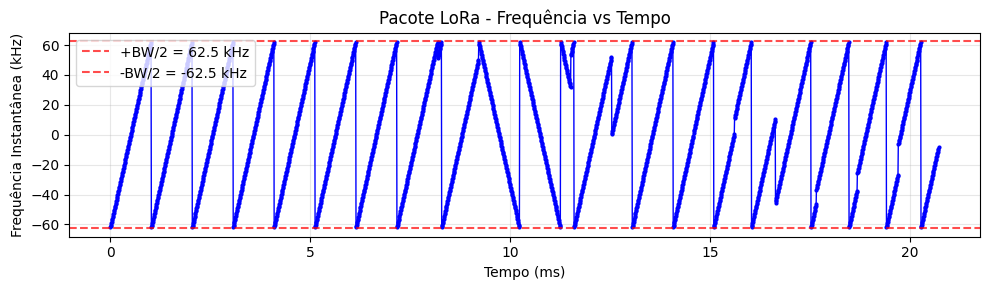

Frequência instantânea calculada para 2591 amostras
Duração total analisada: 20.7 ms


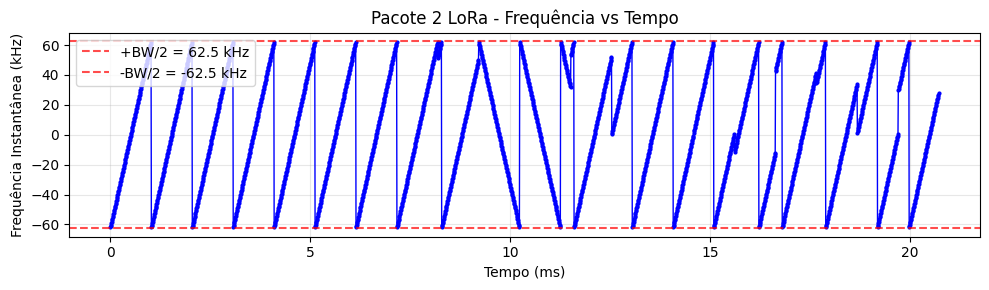

Frequência instantânea calculada para 2591 amostras
Duração total analisada: 20.7 ms

Transmissor LoRa para Sionna implementado e testado com sucesso!


In [14]:
# Análise dos sinais gerados
packet_lengths = [tf.shape(packet)[0] for packet in tf.unstack(lora_packets)]
print(f"Comprimento dos pacotes: {[length.numpy() for length in packet_lengths]} samples")

# Calcular duração temporal dos pacotes
total_duration = packet_lengths[0].numpy() * transmitter.chip_duration.numpy()
print(f"Duração total do pacote: {total_duration*1000:.2f} ms")

# Teste com um único pacote (sem batch)
#print("\n" + "="*50)
#print("Teste com pacote único (sem batch):")
#single_bits = binary_source([num_bits])
#single_packet = transmitter(single_bits)

#print(f"Forma do pacote único: {single_packet.shape}")
#print(f"Primeiros bits: {single_bits[:12].numpy()}")

# Exemplo de análise espectral
#print("\n" + "="*50)
#print("Análise espectral dos chirps:")

#try:
#    spectrums = transmitter.analyze_chirp_spectrum_tensor([0, 32, 64, 96], plot=True)
#    print(f"Forma dos espectros: {spectrums.shape}")
#    print("Análise espectral completada com sucesso!")
#except Exception as e:
#    print(f"Erro na análise espectral: {e}")

# Análise de frequência vs tempo do pacote
print("\n" + "="*50)
print("Análise de frequência vs tempo:")

try:
    # Usar o primeiro pacote do batch para análise detalhada
    single_packet_for_analysis = lora_packets[0]
    freq_inst, time_axis = transmitter.plot_frequency_vs_time(
        single_packet_for_analysis,
        "Pacote LoRa - Frequência vs Tempo"
    )

    print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # Usar o primeiro pacote do batch para análise detalhada
    single_packet_for_analysis = lora_packets[1]
    freq_inst, time_axis = transmitter.plot_frequency_vs_time(
        single_packet_for_analysis,
        "Pacote 2 LoRa - Frequência vs Tempo"
    )

    print(f"Frequência instantânea calculada para {len(freq_inst)} amostras")
    print(f"Duração total analisada: {time_axis[-1]:.1f} ms")

    # Análise estrutural completa
    #sections = transmitter.analyze_lora_packet_structure(single_packet_for_analysis)

except Exception as e:
    print(f"Erro na análise de frequência: {e}")
    import traceback
    traceback.print_exc()

print("\nTransmissor LoRa para Sionna implementado e testado com sucesso!")